# Decision Trees

### Decision Tree Classifier

In [80]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,confusion_matrix

#### Load the dataset

In [81]:
iris = load_iris(as_frame=True).frame
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


### Feature selection

In [82]:
X = iris.drop(columns=["target"])
Y = iris.target
X,Y

(     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
 0                  5.1               3.5                1.4               0.2
 1                  4.9               3.0                1.4               0.2
 2                  4.7               3.2                1.3               0.2
 3                  4.6               3.1                1.5               0.2
 4                  5.0               3.6                1.4               0.2
 ..                 ...               ...                ...               ...
 145                6.7               3.0                5.2               2.3
 146                6.3               2.5                5.0               1.9
 147                6.5               3.0                5.2               2.0
 148                6.2               3.4                5.4               2.3
 149                5.9               3.0                5.1               1.8
 
 [150 rows x 4 columns],
 0      0
 1      0
 2   

In [83]:
# import train_test_split to split data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2)

In [84]:
# Create a Decision Tree model and fit it
tree_clf = DecisionTreeClassifier(criterion="gini",max_depth=5,random_state = 42)
tree_clf.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
y_pred = tree_clf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy of the model : ",accuracy)

Accuracy of the model :  0.9666666666666667


In [86]:
confus_matrix = confusion_matrix(y_test,y_pred)
print("Confusion matrix")
print(confus_matrix)

Confusion matrix
[[11  0  0]
 [ 0  9  1]
 [ 0  0  9]]


In [87]:
tree_clf2 = DecisionTreeClassifier(random_state=42,max_depth=100,criterion="entropy")
tree_clf2.fit(X_train,y_train)
y_pred2 = tree_clf2.predict(X_test)
accuracy2 = accuracy_score(y_test,y_pred2)
confus_matrix2 = confusion_matrix(y_test,y_pred=y_pred2)
print(f"Accuracy of the second model : ",accuracy2)
print(f"Confusion matrix of the second model : ",confus_matrix2)

Accuracy of the second model :  0.9666666666666667
Confusion matrix of the second model :  [[11  0  0]
 [ 0  9  1]
 [ 0  0  9]]


<Axes: xlabel='target'>

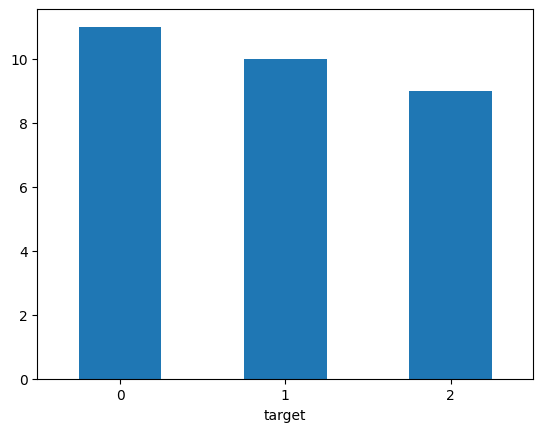

In [88]:
y_test.value_counts().plot(kind="bar",rot = 360)

In [89]:
iris = load_iris()

[Text(0.5, 0.9166666666666666, 'petal length (cm) <= 2.6\ngini = 0.667\nsamples = 120\nvalue = [39, 40, 41]\nclass = virginica'),
 Text(0.4230769230769231, 0.75, 'gini = 0.0\nsamples = 39\nvalue = [39, 0, 0]\nclass = setosa'),
 Text(0.46153846153846156, 0.8333333333333333, 'True  '),
 Text(0.5769230769230769, 0.75, 'petal width (cm) <= 1.75\ngini = 0.5\nsamples = 81\nvalue = [0, 40, 41]\nclass = virginica'),
 Text(0.5384615384615384, 0.8333333333333333, '  False'),
 Text(0.3076923076923077, 0.5833333333333334, 'petal length (cm) <= 4.95\ngini = 0.201\nsamples = 44\nvalue = [0, 39, 5]\nclass = versicolor'),
 Text(0.15384615384615385, 0.4166666666666667, 'sepal length (cm) <= 4.95\ngini = 0.051\nsamples = 38\nvalue = [0, 37, 1]\nclass = versicolor'),
 Text(0.07692307692307693, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.23076923076923078, 0.25, 'gini = 0.0\nsamples = 37\nvalue = [0, 37, 0]\nclass = versicolor'),
 Text(0.46153846153846156, 0.41666666666

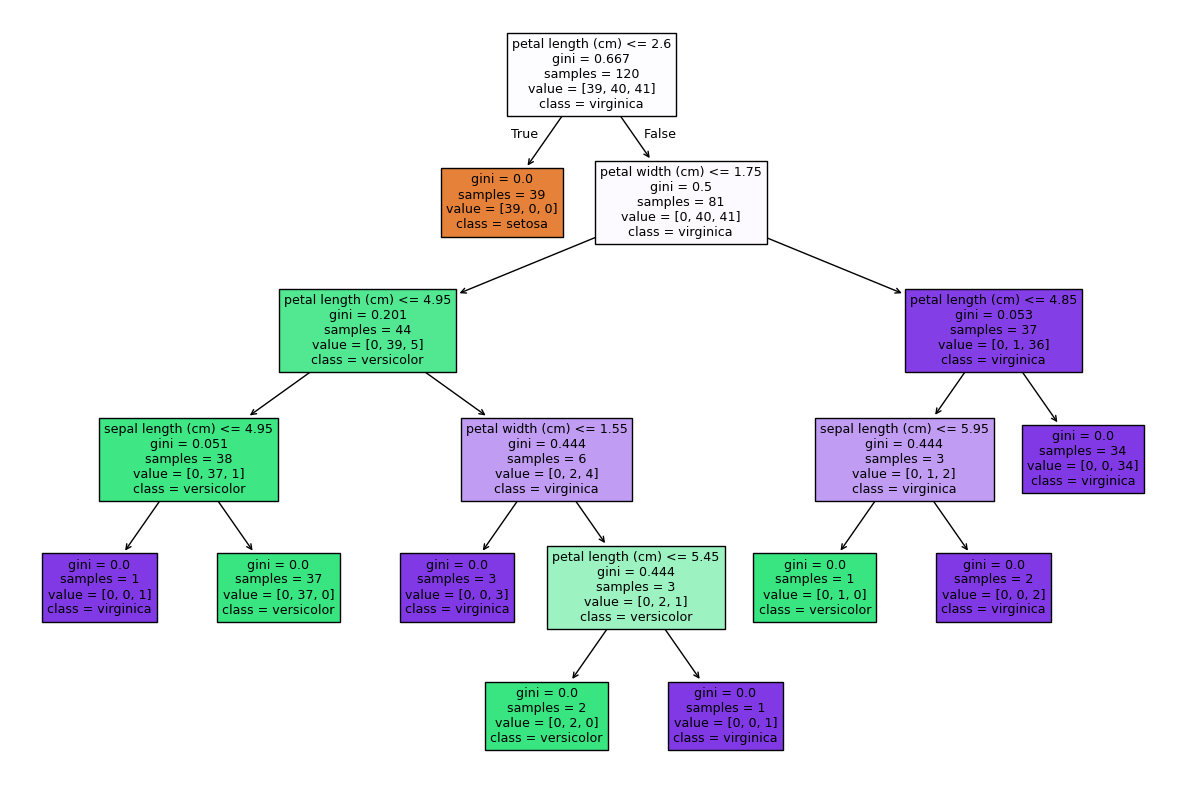

In [90]:
plt.figure(figsize = (15,10))
plot_tree(tree_clf,filled=True,feature_names=iris.feature_names,class_names=iris.target_names)

In [91]:
feature_importances=tree_clf.feature_importances_
feature_names = iris.feature_names
feature_importances_sorted = sorted(zip(feature_importances,feature_names),reverse=True)

for feature_names,feature_importances in feature_importances_sorted:
    print(f"{feature_names} : ",feature_importances)

0.5711821637178895 :  petal length (cm)
0.3878005190778684 :  petal width (cm)
0.041017317204242086 :  sepal length (cm)
0.0 :  sepal width (cm)


## Part-2

In [92]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [93]:
from sklearn.inspection import DecisionBoundaryDisplay
import numpy as np
n_classes = 3
plot_colours = "ryb"

C:\Users\PC\AppData\Local\Temp\ipykernel_17556\2531121029.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx,0],X[idx,1],c = color,label=iris.target_names[i],cmap = plt.cm.RdYlBu,edgecolors="black")
C:\Users\PC\AppData\Local\Temp\ipykernel_17556\2531121029.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx,0],X[idx,1],c = color,label=iris.target_names[i],cmap = plt.cm.RdYlBu,edgecolors="black")
C:\Users\PC\AppData\Local\Temp\ipykernel_17556\2531121029.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx,0],X[idx,1],c = color,label=iris.target_names[i],cmap = plt.cm.RdYlBu,edgecolors="black")
C:\Users\PC\AppData\Local\Temp\ipykernel_17556\2531121029.py:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx,0],X[idx,1],c = color,label=ir

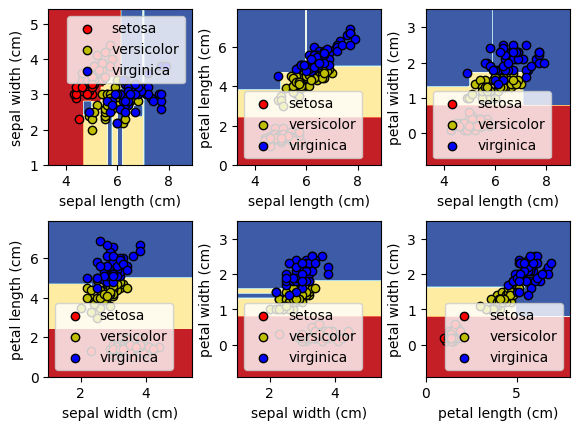

In [94]:
for pairidx,pair in enumerate([[0,1],[0,2],[0,3],[1,2],[1,3],[2,3]]):
    
    X = iris.data[:,pair]
    y = iris.target
    clt = DecisionTreeClassifier().fit(X,y)
    
    ax = plt.subplot(2,3,pairidx + 1)
    plt.tight_layout(h_pad=0.5,w_pad = 0.5,pad= 2.5)
    DecisionBoundaryDisplay.from_estimator(clt,X,cmap = plt.cm.RdYlBu,response_method="predict",ax = ax,xlabel=iris.feature_names[pair[0]],ylabel = iris.feature_names[pair[1]])

    for i,color in zip(range(n_classes),plot_colours):
        idx = np.where(y==i)
        plt.scatter(X[idx,0],X[idx,1],c = color,label=iris.target_names[i],cmap = plt.cm.RdYlBu,edgecolors="black")
        plt.legend()

plt.Figure(figsize=(15,10))
plt.show()

## Decision Tree Regressor

In [95]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor

In [96]:
diabetes = load_diabetes(as_frame = True).frame
diabetes

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [97]:
X  = diabetes.drop(columns = ["target"])
y  = diabetes.target

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

### Decision Tree regression model

In [98]:
tree_reg = DecisionTreeRegressor(random_state=42)
model = tree_reg.fit(X_train,y_train)

In [99]:
# Make predictions and evaluate the results
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)
mse

4976.797752808989

### Part-3

In [100]:
# Create a dataset

In [101]:
X = np.sort(5* np.random.rand(80,1),axis = 0)
X

array([[0.0385238 ],
       [0.05094572],
       [0.28806199],
       [0.28871034],
       [0.29600806],
       [0.31212493],
       [0.43320388],
       [0.47573614],
       [0.49113575],
       [0.60326596],
       [0.61686291],
       [0.69079973],
       [0.90546589],
       [0.90553942],
       [0.94317803],
       [1.00616917],
       [1.01342509],
       [1.23219162],
       [1.38691909],
       [1.42743078],
       [1.47358959],
       [1.48391651],
       [1.50166334],
       [1.56769381],
       [1.57690969],
       [1.61090796],
       [1.68314029],
       [1.72830658],
       [1.88238818],
       [1.96907715],
       [2.02993025],
       [2.03941447],
       [2.08074582],
       [2.12713989],
       [2.13991628],
       [2.18641995],
       [2.33195347],
       [2.37372185],
       [2.48726489],
       [2.49730199],
       [2.57683645],
       [2.60375732],
       [2.61468045],
       [2.65812154],
       [2.69809722],
       [2.72103548],
       [2.7565401 ],
       [2.774

In [102]:
y = np.sin(X).ravel()
y

array([ 0.03851427,  0.05092369,  0.2840946 ,  0.28471618,  0.29170422,
        0.30708159,  0.41978087,  0.45799297,  0.47162769,  0.56733497,
        0.57847909,  0.63715377,  0.78671284,  0.78675823,  0.80942838,
        0.84478817,  0.84864855,  0.94321906,  0.98314216,  0.98974075,
        0.99527914,  0.99622832,  0.99761127,  0.99999519,  0.99998131,
        0.99919564,  0.99369605,  0.98762088,  0.95184675,  0.92172911,
        0.89643665,  0.89219326,  0.87276916,  0.84919169,  0.84237555,
        0.81641348,  0.72403835,  0.69460509,  0.60862599,  0.60063146,
        0.53520989,  0.51227814,  0.50286676,  0.46485525,  0.42909936,
        0.40826914,  0.37560784,  0.35844059,  0.25183702,  0.24698405,
        0.22745302,  0.17102147,  0.12036288,  0.0931127 ,  0.04250222,
        0.03218252,  0.01636606, -0.03580514, -0.19015781, -0.24928677,
       -0.30835091, -0.33978452, -0.36208961, -0.47854881, -0.609556  ,
       -0.80423433, -0.90318069, -0.90601282, -0.96978152, -0.97

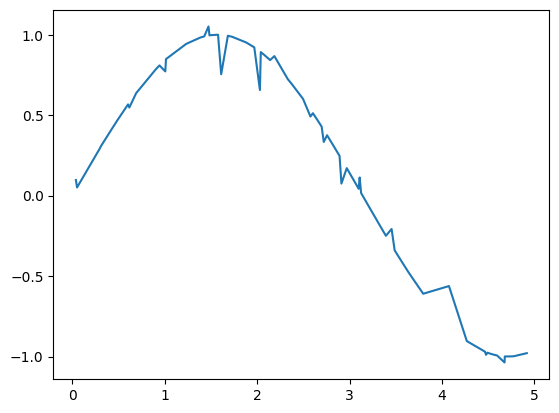

In [107]:
plt.plot(X,y)

In [106]:
y[::5] += 0.5*(0.5-np.random.rand(16))

In [108]:
reg_1 = DecisionTreeRegressor(max_depth=2)
reg_2 = DecisionTreeRegressor(max_depth=5)

reg_1.fit(X,y)
reg_2.fit(X,y)

X_test = np.arange(0,5,step=0.05)[:,np.newaxis]

y_pred_1 =reg_1.predict(X_test)
y_pred_2 =reg_2.predict(X_test)

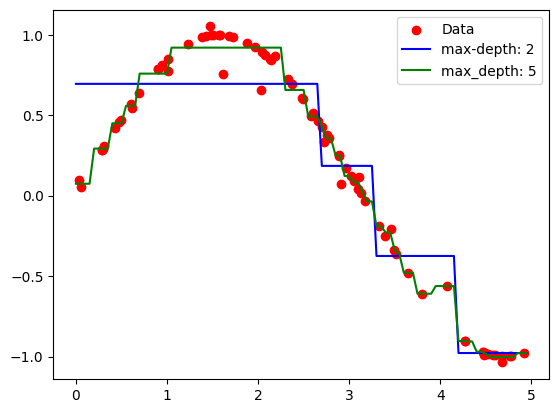

In [110]:
# Visualize the dataset and prediction
plt.scatter(X,y,c = "red",label = "Data")
plt.plot(X_test,y_pred_1,c = "blue",label = "max-depth: 2")
plt.plot(X_test,y_pred_2,c = "green",label = "max_depth: 5")
plt.legend()